# Delivery delays and customer reviews

Notebook 01 measured how long delivery takes and how accurate Olist's promise is. This one
looks at what happens when the promise breaks. How review scores change when an order
arrives late, and where those late orders come from.

## 1. Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'axes.grid': True,
    'grid.alpha': 0.3,
})

In [2]:
clean = pd.read_parquet("../data/clean/clean.parquet")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")

print("clean: ", clean.shape)
print("reviews: ", reviews.shape)

clean:  (96470, 37)
reviews:  (99224, 7)


In [3]:
reviews['review_score'].value_counts()

review_score
5    57328
4    19142
1    11424
3     8179
2     3151
Name: count, dtype: int64

In [4]:
print("Unique: ", reviews['order_id'].nunique())

Unique:  98673


In [5]:
main_review = (reviews
               .sort_values(['review_creation_date'], ascending=False)
               .drop_duplicates('order_id'))

print("Cleaned reviews",main_review.shape)

Cleaned reviews (98673, 7)


In [6]:
df = clean.merge(main_review[['order_id', 'review_score', 'review_creation_date']], on='order_id', how='inner')
print("Length before merge: ", len(clean))
print("Length after merge: ", len(df))

Length before merge:  96470
Length after merge:  95824


646 delivered orders have no review, 0.7% of the total.

In [7]:
df['days_late'] = df['delivery_days'] - df['estimated_days']

days_late is the gap between actual and promised delivery. Positive means the order
arrived after the promised date, negative means it came early.

## 2. Delivery delay & review score

In [8]:
print(df.groupby('is_late')['review_score'].agg(['mean', 'count']).round(2))

         mean  count
is_late             
0        4.29  89443
1        2.27   6381


Late orders average 2.27 against 4.29 for on-time ones. A broken promise costs roughly
two stars. Only 6,381 orders out of 95,824 arrive late, but each one lands near the
bottom of the scale.

In [9]:
df['late_bin'] = pd.cut(df['days_late'], bins=[-200, -14, -7, -3, 0, 3, 7, 14, 200])

In [10]:
by_bin = df.groupby('late_bin', observed=True)['review_score'].agg(['mean', 'count']).round(2).reset_index()
print(by_bin)

      late_bin  mean  count
0  (-200, -14]  4.32  41861
1    (-14, -7]  4.30  33883
2     (-7, -3]  4.19   9429
3      (-3, 0]  4.11   4270
4       (0, 3]  3.29   1852
5       (3, 7]  2.10   1748
6      (7, 14]  1.67   1446
7    (14, 200]  1.72   1335


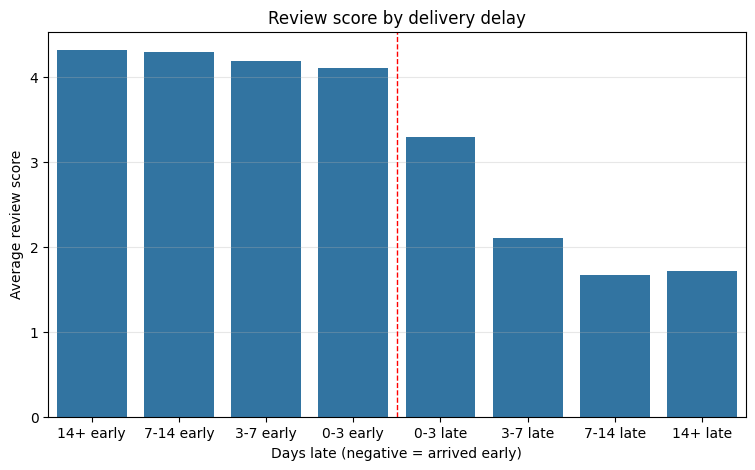

In [11]:
plt.figure(figsize=(9, 5))
sns.barplot(data=by_bin, x='late_bin', y='mean')
plt.axvline(3.5, color='red', linestyle='--', linewidth=1)
plt.title('Review score by delivery delay')
plt.xlabel('Days late (negative = arrived early)')
plt.ylabel('Average review score')
labels = ['14+ early', '7-14 early', '3-7 early', '0-3 early',
          '0-3 late', '3-7 late', '7-14 late', '14+ late']
plt.xticks(range(8), labels)
plt.savefig('../images/score_by_delay.png')
plt.show()

Arriving early buys nothing. Scores hold at 4.1 to 4.3 whether the order came one day
ahead or two weeks ahead.

Crossing the promised date is what hurts. One to three days late drops the score from
4.11 to 3.29. Beyond a week it bottoms out near 1.7 and stops falling.

The penalty is one-sided, which is why Olist pads the promise with a 12-day buffer
instead of tightening it.

In [12]:
low = df[df['review_score'] <= 2]

In [13]:
print("Late among all orders:", df['is_late'].mean().round(3))
print("Late among 1-2 star orders:", low['is_late'].mean().round(3))

Late among all orders: 0.067
Late among 1-2 star orders: 0.325


Late orders are 6.7% of all deliveries but 32.5% of 1-2 star reviews. A customer who
gets a late parcel is about five times more likely to leave a bad rating.

The other two thirds of bad reviews have nothing to do with delivery time. Product
quality, wrong items and seller communication are outside this dataset.

## 3. Where late orders concentrate

### Sellers

In [14]:
state_late = df.groupby('customer_state')['is_late'].mean()
df['expected_late'] = df['customer_state'].map(state_late)

sellers = (df.groupby('seller_id')
           .agg(orders=('order_id', 'count'),
                late_orders=('is_late', 'sum'),
                expected_late=('expected_late', 'sum'),
                avg_score=('review_score', 'mean')))

sellers['excess_late'] = sellers['late_orders'] - sellers['expected_late']

top = sellers.query('orders >= 50').sort_values('excess_late', ascending=False)

print("Total late orders:", df['is_late'].sum())
print("Total excess over route baseline (sellers with >=50 orders):",
      round(top['excess_late'].clip(lower=0).sum(), 1))
print("\nTop 25 by excess:")
print(top.head(25).round(2).to_string())
print("\nExcess from top 25:", round(top.head(25)['excess_late'].sum(), 1))

Total late orders: 6381
Total excess over route baseline (sellers with >=50 orders): 992.9

Top 25 by excess:
                                  orders  late_orders  expected_late  avg_score  excess_late
seller_id                                                                                   
4a3ca9315b744ce9f8e9374361493884    1703          168         110.54       3.88        57.46
06a2c3af7b3aee5d69171b0e14f0ee87     384           71          29.29       4.02        41.71
4869f7a5dfa277a7dca6462dcf3b52b2    1106          116          78.32       4.17        37.68
88460e8ebdecbfecb5f9601833981930     231           41          13.87       3.48        27.13
1f50f920176fa81dab994f9023523100    1370          121          95.63       4.17        25.37
7d13fca15225358621be4086e1eb0964     553           64          39.03       4.05        24.97
8160255418d5aaa7dbdc9f4c64ebda44     369           49          24.72       3.99        24.28
e5a3438891c0bfdb9394643f95273d8e     212           34

In [15]:
s = sellers.query('orders >= 50').copy()
s['lift'] = s['late_orders'] / s['expected_late']

rows = []
for lift_min in [1.25, 1.5, 1.75, 2.0]:
    for exc_min in [5, 10, 20]:
        f = s[(s['lift'] >= lift_min) & (s['excess_late'] >= exc_min)]
        rows.append({
            'lift_min': lift_min,
            'excess_min': exc_min,
            'sellers': len(f),
            'excess': round(f['excess_late'].sum(), 1),
            'pct_of_late': round(f['excess_late'].sum() / df['is_late'].sum() * 100, 1),
            'pct_of_orders': round(f['orders'].sum() / len(df) * 100, 1),
        })

print(pd.DataFrame(rows).to_string(index=False))

 lift_min  excess_min  sellers  excess  pct_of_late  pct_of_orders
     1.25           5       64   750.7         11.8           18.2
     1.25          10       21   441.0          6.9           10.7
     1.25          20        8   259.1          4.1            6.2
     1.50           5       49   560.9          8.8            9.5
     1.50          10       16   327.6          5.1            5.4
     1.50          20        6   196.1          3.1            3.6
     1.75           5       36   388.3          6.1            4.9
     1.75          10       13   226.9          3.6            2.6
     1.75          20        4   113.6          1.8            1.2
     2.00           5       26   281.8          4.4            2.9
     2.00          10        9   161.7          2.5            1.5
     2.00          20        3    89.4          1.4            0.9


In [16]:
flagged = s[(s['lift'] >= 1.5) & (s['excess_late'] >= 10)].sort_values('excess_late', ascending=False)

print("Sellers with >=50 orders:", len(s))
print("Flagged:", len(flagged))
print("Their excess:", round(flagged['excess_late'].sum(), 1))
print("Share of all late orders:", round(flagged['excess_late'].sum() / df['is_late'].sum() * 100, 1), "%")
print("Their order volume:", int(flagged['orders'].sum()),
      f"({flagged['orders'].sum() / len(df) * 100:.1f}% of all orders)")
print(flagged[['orders','late_orders','expected_late','excess_late','lift','avg_score']].round(2).to_string())

Sellers with >=50 orders: 413
Flagged: 16
Their excess: 327.6
Share of all late orders: 5.1 %
Their order volume: 5172 (5.4% of all orders)
                                  orders  late_orders  expected_late  excess_late  lift  avg_score
seller_id                                                                                         
4a3ca9315b744ce9f8e9374361493884    1703          168         110.54        57.46  1.52       3.88
06a2c3af7b3aee5d69171b0e14f0ee87     384           71          29.29        41.71  2.42       4.02
88460e8ebdecbfecb5f9601833981930     231           41          13.87        27.13  2.96       3.48
7d13fca15225358621be4086e1eb0964     553           64          39.03        24.97  1.64       4.05
8160255418d5aaa7dbdc9f4c64ebda44     369           49          24.72        24.28  1.98       3.99
e5a3438891c0bfdb9394643f95273d8e     212           34          13.47        20.53  2.52       4.01
1835b56ce799e6a4dc4eddc053f04066     397           43          24.78

Late rate mixes how the seller works with where the parcel goes. Each seller is compared
against the average late rate on their own destinations.

Sellers explain little: 11.8% of late orders at the loosest threshold, and 5.1% at the cut
used here (1.5x the baseline, 10+ excess orders, 16 sellers).

Late deliveries at Olist are mostly systemic.

In [17]:
by_seller = (df.groupby('seller_id')
                 .agg(orders = ('order_id', 'count'),
                      late_orders = ('is_late', 'sum'),
                      late_rate = ('is_late', 'mean'),
                      avg_score = ('review_score', 'mean')))


print("Total sellers: ", len(by_seller))

Total sellers:  2954


In [18]:
total_late = df['is_late'].sum()
top_50 = by_seller.sort_values('late_orders', ascending=False).head(50)['late_orders']

print("Late orders total:", total_late)
print("From top 50 sellers:", top_50.sum())
print("Share:", round(top_50.sum() / total_late * 100, 2), "%")

Late orders total: 6381
From top 50 sellers: 2441
Share: 38.25 %


Ranking by volume gives a different answer: 50 sellers carry 2,441 of 6,381 late orders,
38%. That measures seller size, not seller quality. The largest of them has 168 late orders
against 110 expected on its routes, so 57 are excess, not 168.

This is why the ranking above uses excess over the route baseline.

### Categories

In [19]:
by_category = (df.groupby('product_category_name')
               .agg(orders = ('order_id', 'count'),
                    late_rate = ('is_late', 'mean'),
                    avg_score = ('review_score', 'mean'))
               .query('orders>500')
               .sort_values('late_rate', ascending=False))

print(by_category)

                                   orders  late_rate  avg_score
product_category_name                                          
moveis_escritorio                    1241   0.079774   3.646253
bebes                                2739   0.079591   4.121212
eletronicos                          2483   0.076520   4.129279
instrumentos_musicais                 602   0.076412   4.242525
beleza_saude                         8567   0.073888   4.233220
cama_mesa_banho                      9090   0.073267   4.006821
relogios_presentes                   5436   0.072664   4.122517
automotivo                           3774   0.072337   4.153153
construcao_ferramentas_construcao     719   0.072323   4.151599
moveis_decoracao                     6142   0.071475   4.078476
unknown                              1349   0.071164   4.037806
telefonia                            4049   0.070882   4.059274
papelaria                            2231   0.065442   4.306589
perfumaria                           305

Category late rate runs 4.2% to 8.0%, and average score sits between 4.0 and 4.4 almost
everywhere. Office furniture is the only outlier at 3.65.

Like sellers, category explains little once the route baseline is taken into account.

### Time

In [20]:
df['purchase_ym'] = df['order_purchase_timestamp'].dt.to_period('M')

In [21]:
by_month = (df.groupby('purchase_ym')
            .agg(orders = ('order_id', 'count'),
                 late_rate = ('is_late', 'mean'),
                 avg_score = ('review_score', 'mean')))

print(by_month)

             orders  late_rate  avg_score
purchase_ym                              
2016-09           1   1.000000   1.000000
2016-10         262   0.007634   4.011450
2016-12           1   0.000000   5.000000
2017-01         741   0.028340   4.198381
2017-02        1643   0.025563   4.203287
2017-03        2527   0.044717   4.187970
2017-04        2290   0.064192   4.136681
2017-05        3517   0.028149   4.235712
2017-06        3111   0.029572   4.222437
2017-07        3842   0.027330   4.257939
2017-08        4165   0.029052   4.312845
2017-09        4118   0.042982   4.267606
2017-10        4446   0.040261   4.204903
2017-11        7237   0.122565   3.987840
2017-12        5461   0.073430   4.088445
2018-01        7013   0.056467   4.109083
2018-02        6507   0.140157   3.880590
2018-03        6948   0.186528   3.812464
2018-04        6752   0.043987   4.206457
2018-05        6722   0.065010   4.236537
2018-06        6072   0.011693   4.307312
2018-07        6118   0.032690   4

Late rate is not stable. It sits around 0.03 for most months, then jumps to 0.12 in
November 2017 and to 0.14 and 0.19 in February and March 2018. Average score drops at
the same time, down to 3.81 in the worst month.

November had more orders than usual, 7,237 against 4,446 the month before. The same
network handles a normal month fine and breaks under load. Black Friday is the likely
reason for that volume.

The first and last rows of 2016 have one order each and are ignored.

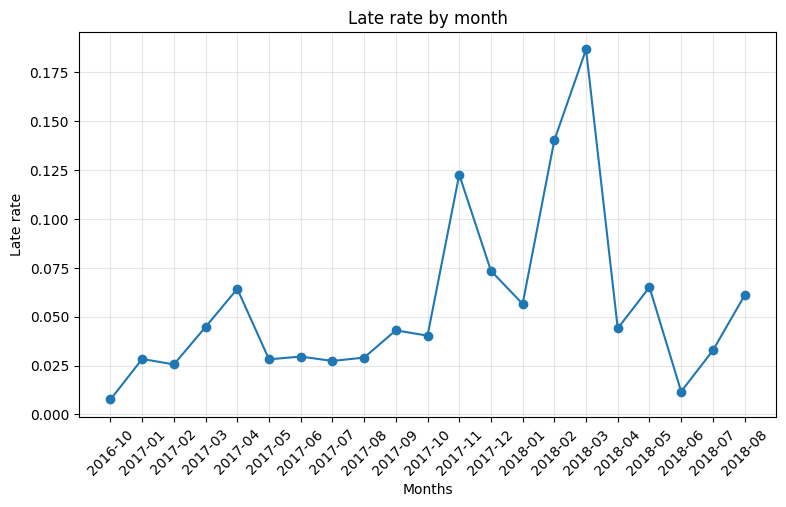

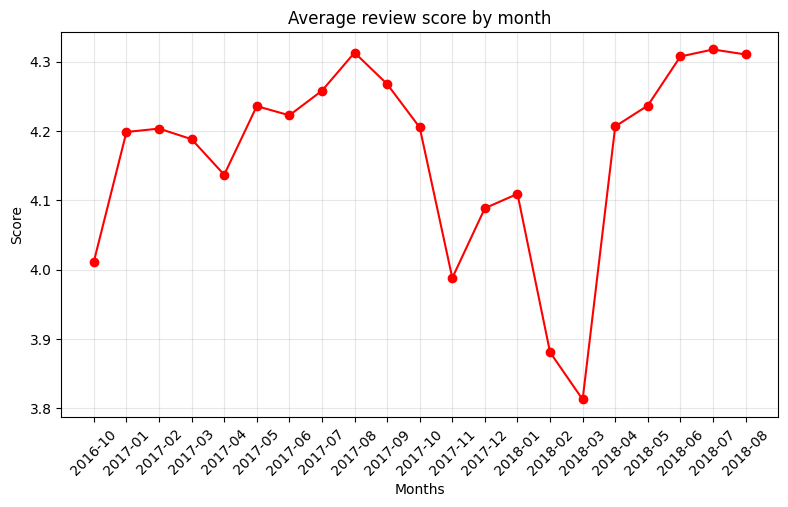

In [22]:
by_month_plot = by_month[by_month['orders'] >= 100].reset_index()
by_month_plot['purchase_ym'] = by_month_plot['purchase_ym'].astype(str)

plt.figure(figsize=(9,5))
plt.plot(by_month_plot['purchase_ym'], by_month_plot['late_rate'], marker='o')
plt.title('Late rate by month')
plt.ylabel('Late rate')
plt.xlabel('Months')
plt.xticks(rotation = 45)
plt.savefig('../images/late_rate_by_month.png')
plt.show()

plt.figure(figsize=(9.25,5))
plt.plot(by_month_plot['purchase_ym'], by_month_plot['avg_score'], marker = 'o', color='red')
plt.title('Average review score by month')
plt.ylabel('Score')
plt.xlabel('Months')
plt.xticks(rotation=45)
plt.savefig('../images/score_by_month.png')
plt.show()

## Findings

1. A late order averages **2.27** stars. An on-time one averages **4.29**.

2. Arriving early buys nothing. Scores hold at **4.1 to 4.3** whether the parcel came a day
   ahead or two weeks ahead. The drop starts once the promised date passes and bottoms out
   at **1.7** after a week.

3. Late orders are **6.7%** of all deliveries and **32.5%** of 1-2 star reviews.

4. Sellers explain **5.1%** of late deliveries (16 sellers, 328 excess orders), and at most
   **11.8%** at the loosest threshold.

5. Category barely moves the number. Late rate spikes in November and February.

## Recommendations

1. Plan for demand peaks. November 2017 and March 2018 hit **0.12** and **0.19** late rate
   against **0.03** in a normal month, and the promise did not move.

2. Look at shortening the promise where delivery is reliable. Notebook 01 shows a 12-day
   buffer, and early delivery does not improve the score.

3. SLA for the 16 flagged sellers. A small lever at 5.1% of late orders, but the list is
   short and the excess is measured against their own routes.